# TabNet — GP2 Tabular SSL Research

**Student:** Zain Qerba (160201)  
**Supervisor:** Dana El Rushaidat  
**University:** Jordan University of Science and Technology  

---

## Purpose
This notebook trains **TabNet** on the Forest Cover Type (Covertype) dataset
at 8 data fractions (100%, 50%, 10%, 8%, 6%, 4%, 2%, 1%).

TabNet uses **sequential attention** to select the most salient features at each
decision step — making it both interpretable and efficient. It also supports
**self-supervised pretraining via masked feature reconstruction**, which we
attempt here on Covertype despite the original paper only demonstrating SSL
on the Higgs Boson dataset.

This experiment investigates whether TabNet's SSL pretraining can improve
performance on a large-scale dataset (464k samples, 54 features) that the
The paper did not test SSL on — and identifies the **crossover point** where
TabNet outperforms XGBoost as labeled data decreases.

## Dataset
| Dataset | Task | Rows | Features |
|---|---|---|---|
| Forest Cover Type (Covertype) | Multiclass classification (7 classes) | 581,012 | 54 |

## Metrics
- **Accuracy** — overall correctness across all 7 classes
- **Macro-F1** — treats all 7 classes equally regardless of size

## SSL Approach
- **Pretraining:** masked feature reconstruction — 50% of features masked per row, model reconstructs them without using labels
- **Finetuning:** supervised classification initialized from pretrained weights

## Citation
Arik, S. Ö., & Pfister, T. (2021). TabNet: Attentive Interpretable Tabular Learning.
*AAAI 2021*. https://doi.org/10.1609/aaai.v35i8.16826

In [1]:
# ── Cell 1: Install Dependencies ──────────────────────────────────────────────

!pip install pytorch-tabnet scikit-learn pandas numpy matplotlib seaborn -q
print("All packages installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 750.2 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 56.2 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incomp

In [2]:
# ── Cell 2: Imports & Config ───────────────────────────────────────────────────
# All hyperparameters are defined here 
# Supervised finetuning params follow the TabNet paper (Arik & Pfister, 2021).
# SSL pretraining params are adjusted for numerical stability on large datasets
# (smaller batch size, lower LR) .

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import torch
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

from pytorch_tabnet.pretraining import TabNetPretrainer
from pytorch_tabnet.tab_model import TabNetClassifier

RANDOM_STATE      = 42
FRACTIONS         = [1.0, 0.5, 0.1, 0.08, 0.06, 0.04, 0.02, 0.01]
RESULTS_FILE      = 'tabnet_results.csv'

# ── Architecture (from paper Table 9 — Covertype) ─────────────────────────────
N_D               = 64
N_A               = 64
N_STEPS           = 6
GAMMA             = 1.5
MASK_TYPE         = 'sparsemax'
LAMBDA_SPARSE     = 0.0001

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE        = 16384       # paper value — used for finetuning
VIRTUAL_BATCH     = 512         # ghost batch normalization
BATCH_MOMENTUM    = 0.02        # paper uses low momentum for stable BN
PRETRAIN_LR       = 0.005       # lower LR for stable SSL pretraining
LR                = 0.02        # finetuning LR from paper
PRETRAIN_EPOCHS   = 200
FINETUNE_EPOCHS   = 300
PRETRAIN_PATIENCE = 50
FINETUNE_PATIENCE = 80

In [3]:
# ── Cell 3: Load Data & Train/Test Split ───────────────────────────────────────
# Covertype has 7 forest cover type classes (originally labeled 1-7).
# We shift to 0-6 for PyTorch compatibility.
# 80/20 stratified split ensures all 7 classes are represented in both sets.

print("Loading Covertype dataset...")
cov   = fetch_covtype()
X_all = cov.data.astype(np.float32)
y_all = (cov.target - 1).astype(int)   # shift 1-7 → 0-6

X_cov_train, X_cov_test, y_cov_train, y_cov_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_all
)

print(f"Full train : {X_cov_train.shape}")
print(f"Test       : {X_cov_test.shape}")
print(f"Classes    : {np.unique(y_all)}")

Loading Covertype dataset...
Full train : (464809, 54)
Test       : (116203, 54)
Classes    : [0 1 2 3 4 5 6]


In [4]:
# ── Cell 4: Helper Functions ───────────────────────────────────────────────────

def save_result(row):
    # Append result to CSV, overwriting any existing row for same dataset+fraction
    df_new = pd.DataFrame([row])
    if os.path.exists(RESULTS_FILE):
        df_existing = pd.read_csv(RESULTS_FILE)
        df_existing = df_existing[~(
            (df_existing['dataset'] == row['dataset']) &
            (df_existing['fraction'] == row['fraction'])
        )]
        df_new = pd.concat([df_existing, df_new], ignore_index=True)
    df_new.to_csv(RESULTS_FILE, index=False)

def get_completed_fractions():
    # Returns list of already-completed fractions to allow resuming interrupted runs
    if not os.path.exists(RESULTS_FILE):
        return []
    df = pd.read_csv(RESULTS_FILE)
    return df[df['dataset'] == 'covertype']['fraction'].tolist()

def get_batch_sizes(n_samples):
    # Adaptive batch sizing — prevents Ghost BN collapse when dataset is smaller than BATCH_SIZE
    # virtual_batch_size must exactly divide batch_size (Ghost BN requirement)
    batch_sz  = min(BATCH_SIZE, n_samples // 4)
    batch_sz  = max(batch_sz, 64)
    vbatch_sz = min(VIRTUAL_BATCH, batch_sz // 4)
    vbatch_sz = max(vbatch_sz, 32)
    vbatch_sz = batch_sz // (batch_sz // vbatch_sz)
    return batch_sz, vbatch_sz

In [5]:
# ── Cell 5: Training Loop ──────────────────────────────────────────────────────
# For each fraction:
#   1. Subsample training data (stratified)
#   2. Normalize with StandardScaler (fit on train only)
#   3. SSL pretraining — masked feature reconstruction, no labels used
#   4. Supervised finetuning — initialized from pretrained weights
#   5. Evaluate and save results

if os.path.exists(RESULTS_FILE):
    os.remove(RESULTS_FILE)
    print("Results file cleared.")

print("=" * 60)
print("COVERTYPE — TabNet SSL across 8 data fractions")
print("=" * 60)

completed = get_completed_fractions()

for frac in FRACTIONS:
    if frac in completed:
        print(f"\nFraction: {int(frac*100)}% — already done, skipping")
        continue

    print(f"\nFraction: {int(frac*100)}%")

    # stratified subsample
    if frac == 1.0:
        X_tr, y_tr = X_cov_train.copy(), y_cov_train.copy()
    else:
        n_samples = int(len(X_cov_train) * frac)
        _, X_tr, _, y_tr = train_test_split(
            X_cov_train, y_cov_train,
            test_size=n_samples,
            random_state=RANDOM_STATE,
            stratify=y_cov_train
        )

    print(f"  Training samples : {len(X_tr):,}")

    # normalize — fit on train split only to prevent data leakage
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr).astype(np.float32)
    X_te_sc = scaler.transform(X_cov_test).astype(np.float32)

    # adaptive batch sizes for finetuning
    batch_sz, vbatch_sz = get_batch_sizes(len(X_tr_sc))

    # smaller pretrain batch for numerical stability on large datasets
    pretrain_batch  = min(batch_sz, 2048)
    pretrain_vbatch = pretrain_batch // (pretrain_batch // min(256, pretrain_batch // 4))
    pretrain_vbatch = max(pretrain_vbatch, 32)

    print(f"  finetune  batch  : {batch_sz} / {vbatch_sz}")
    print(f"  pretrain  batch  : {pretrain_batch} / {pretrain_vbatch}")

    # SSL pretraining — labels are never passed here
    pretrainer = TabNetPretrainer(
        n_d=N_D, n_a=N_A, n_steps=N_STEPS, gamma=GAMMA,
        n_independent=2, n_shared=2,
        mask_type=MASK_TYPE, momentum=BATCH_MOMENTUM,
        lambda_sparse=LAMBDA_SPARSE,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=PRETRAIN_LR),
        seed=RANDOM_STATE, verbose=0
    )
    pretrainer.fit(
        X_train=X_tr_sc,
        eval_set=[X_te_sc],
        max_epochs=PRETRAIN_EPOCHS,
        patience=PRETRAIN_PATIENCE,
        batch_size=pretrain_batch,
        virtual_batch_size=pretrain_vbatch,
        pretraining_ratio=0.5
    )
    ssl_worked = pretrainer.best_epoch > 5
    print(f"  Pretraining — best_epoch: {pretrainer.best_epoch} | SSL={'SUCCESS' if ssl_worked else 'FAILED'}")

    # supervised finetuning — initialized from pretrained weights
    model = TabNetClassifier(
        n_d=N_D, n_a=N_A, n_steps=N_STEPS, gamma=GAMMA,
        n_independent=2, n_shared=2,
        mask_type=MASK_TYPE, momentum=BATCH_MOMENTUM,
        lambda_sparse=LAMBDA_SPARSE,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=LR),
        seed=RANDOM_STATE, verbose=0
    )
    model.fit(
        X_train=X_tr_sc, y_train=y_tr,
        eval_set=[(X_te_sc, y_cov_test)],
        eval_metric=['accuracy'],
        from_unsupervised=pretrainer,
        max_epochs=FINETUNE_EPOCHS,
        patience=FINETUNE_PATIENCE,
        batch_size=batch_sz,
        virtual_batch_size=vbatch_sz
    )

    y_pred = model.predict(X_te_sc)
    acc = accuracy_score(y_cov_test, y_pred)
    f1  = f1_score(y_cov_test, y_pred, average='macro')

    print(f"  TEST → Accuracy: {acc:.4f}  |  Macro-F1: {f1:.4f}")

    save_result({
        'dataset': 'covertype', 'model': 'tabnet', 'fraction': frac,
        'n_train_samples': len(X_tr),
        'accuracy': round(acc, 4), 'macro_f1': round(f1, 4),
        'roc_auc': None, 'pr_auc': None, 'f1': None,
        'rmse': None, 'mae': None, 'r2': None,
        'ssl_pretrain_success': ssl_worked,
        'best_pretrain_epoch': pretrainer.best_epoch,
        'best_optuna_params': f'n_d={N_D},n_a={N_A},n_steps={N_STEPS},gamma={GAMMA},mask={MASK_TYPE},lambda={LAMBDA_SPARSE},pretrain_batch={pretrain_batch},finetune_batch={batch_sz},pretrain_lr={PRETRAIN_LR},finetune_lr={LR}'
    })
    print(f"  Saved: dataset=covertype | fraction={frac}")

print("\nCovertype TabNet experiments complete.")

COVERTYPE — TabNet SSL across 8 data fractions

Fraction: 100%
  Training samples : 464,809
  finetune  batch  : 16384 / 512
  pretrain  batch  : 2048 / 256

Early stopping occurred at epoch 50 with best_epoch = 0 and best_val_0_unsup_loss_numpy = 812633179553792.0
  Pretraining — best_epoch: 0 | SSL=FAILED
Stop training because you reached max_epochs = 300 with best_epoch = 297 and best_val_0_accuracy = 0.96398
  TEST → Accuracy: 0.9640  |  Macro-F1: 0.9390
  Saved: dataset=covertype | fraction=1.0

Fraction: 50%
  Training samples : 232,404
  finetune  batch  : 16384 / 512
  pretrain  batch  : 2048 / 256

Early stopping occurred at epoch 50 with best_epoch = 0 and best_val_0_unsup_loss_numpy = 8188318105731072.0
  Pretraining — best_epoch: 0 | SSL=FAILED
Stop training because you reached max_epochs = 300 with best_epoch = 286 and best_val_0_accuracy = 0.93689
  TEST → Accuracy: 0.9369  |  Macro-F1: 0.8830
  Saved: dataset=covertype | fraction=0.5

Fraction: 10%
  Training samples : 4

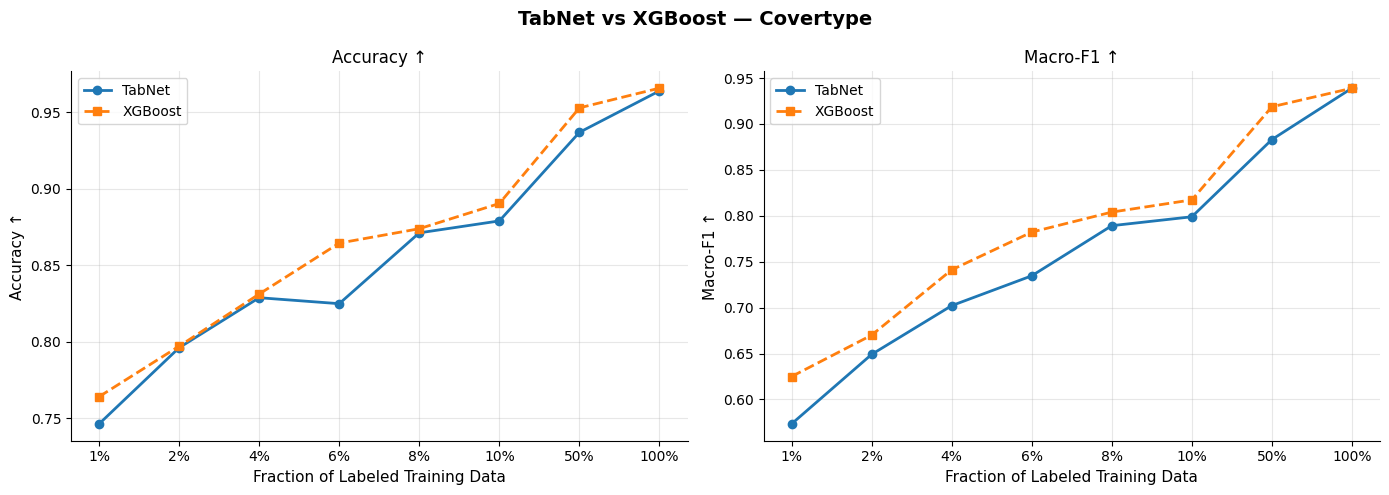

Plot saved.


In [14]:
# ── Cell 6: Visualization — TabNet vs XGBoost on Covertype ────────────────────
# Evenly spaced x-axis so small fractions (1%-10%) don't crowd together.
# XGBoost results loaded from uploaded dataset input.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# load TabNet results
tab = pd.read_csv('tabnet_results.csv')
tab = tab[tab['dataset'] == 'covertype'].sort_values('fraction').reset_index(drop=True)

# load XGBoost results
xgb = pd.read_csv('/kaggle/input/datasets/lelyzain57/xgboost-results/xgboost_results.csv')
xgb = xgb[xgb['dataset'] == 'covertype'].sort_values('fraction').reset_index(drop=True)

x_pos    = np.arange(len(tab))
x_labels = [f"{int(f*100)}%" for f in tab['fraction'].values]

BLUE   = '#1f77b4'
ORANGE = '#ff7f0e'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TabNet vs XGBoost — Covertype', fontsize=14, fontweight='bold')

for ax, (col, ylabel) in zip(axes, [('accuracy', 'Accuracy ↑'), ('macro_f1', 'Macro-F1 ↑')]):
    ax.plot(x_pos, tab[col].values,
            marker='o', linewidth=2, color=BLUE, label='TabNet')
    ax.plot(x_pos, xgb[col].values,
            marker='s', linewidth=2, color=ORANGE, linestyle='--', label='XGBoost')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_xlabel('Fraction of Labeled Training Data', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(ylabel, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('tabnet_covertype_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")